# Comparação de Desempenho: Pandas, PyArrow e Polars

Este notebook compara o desempenho das bibliotecas usadas para consultas em grande volume no arquivo `trabalho/censo-escolar.csv`.

As consultas foram escolhidas com base no notebook `3-operacoes-grandes-volumes-censo-escolar.ipynb` e no contrato do schema Pandera: agrupamento por `ano_censo`, métricas quantitativas e completude das colunas do schema.

## 1) Configuração

In [ ]:
from pathlib import Path
import gc
import resource

import time

import matplotlib.pyplot as plt
import pandas as pd

RAIZ_PROJETO = Path.cwd()
if not (RAIZ_PROJETO / 'trabalho').exists() and (RAIZ_PROJETO.parent / 'trabalho').exists():
    RAIZ_PROJETO = RAIZ_PROJETO.parent

CSV_PATH = RAIZ_PROJETO / 'trabalho' / 'censo-escolar.csv'
BATCH_SIZE = 200_000
REPETICOES = 1
MAX_LINHAS_TESTE = None  # use um inteiro, como 1_000_000, para teste rápido

if not CSV_PATH.exists():
    raise FileNotFoundError(f'CSV consolidado não encontrado: {CSV_PATH}')

print(f'Fonte: {CSV_PATH}')
print(f'Tamanho: {CSV_PATH.stat().st_size / 1024**2:.1f} MB')
print(f'Batch size Pandas: {BATCH_SIZE:,} linhas')
print(f'Repetições por benchmark: {REPETICOES}')
print(f'Limite de linhas para teste: {MAX_LINHAS_TESTE}')

Fonte: /home/gabriel/ciencias-computacao/programacao-para-analise-de-dados/trabalho/censo-escolar.csv
Tamanho: 1074.8 MB
Batch size Pandas: 200,000 linhas
Repetições por benchmark: 1
Limite de linhas para teste: None


## 2) Bibliotecas e Colunas das Consultas

In [2]:
BIBLIOTECAS = {
    'Pandas': importlib.util.find_spec('pandas') is not None,
    'PyArrow': importlib.util.find_spec('pyarrow') is not None,
    'Polars': importlib.util.find_spec('polars') is not None,
}
display(pd.DataFrame({'biblioteca': BIBLIOTECAS.keys(), 'disponivel': BIBLIOTECAS.values()}))

COLUNAS_ESPERADAS = [
    'ano_censo', 'id_escola', 'co_municipio', 'no_municipio', 'sg_uf', 'co_uf', 'no_uf',
    'no_regiao', 'co_regiao', 'no_entidade', 'dependencia_administrativa', 'localizacao',
    'situacao_funcionamento', 'tp_localizacao_diferenciada', 'tp_categoria_escola_privada',
    'in_regular', 'in_creche', 'in_pre_escola', 'in_fundamental', 'in_medio', 'in_eja',
    'in_profissionalizante', 'in_especial', 'in_educacao_indigena', 'in_predio_escolar',
    'in_predio_compartilhado', 'in_agua_potavel', 'in_agua_rede_publica',
    'in_agua_poco_artesiano', 'in_agua_inexistente', 'in_energia_rede_publica',
    'in_energia_gerador', 'in_energia_inexistente', 'qt_mat_bas', 'qt_mat_fund',
    'qt_mat_med', 'qt_doc_bas', 'qt_doc_fund', 'qt_doc_med', 'qt_tur_bas',
    'qt_tur_fund', 'qt_tur_med',
]

COLUNAS_PERFIL = [
    'ano_censo', 'id_escola', 'situacao_funcionamento',
    'qt_mat_bas', 'qt_doc_bas', 'qt_tur_bas', 'in_creche', 'in_medio',
]
COLUNAS_NUMERICAS_PERFIL = ['ano_censo', 'qt_mat_bas', 'qt_doc_bas', 'qt_tur_bas', 'in_creche', 'in_medio']
COLUNAS_COMPLETUDE = [coluna for coluna in COLUNAS_ESPERADAS if coluna != 'ano_censo']

colunas_csv = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
faltantes = [coluna for coluna in COLUNAS_ESPERADAS if coluna not in colunas_csv]
extras = [coluna for coluna in colunas_csv if coluna not in COLUNAS_ESPERADAS]

print(f'Colunas esperadas: {len(COLUNAS_ESPERADAS)}')
print(f'Colunas no CSV: {len(colunas_csv)}')
print(f'Colunas ausentes: {faltantes}')
print(f'Colunas extras: {extras}')

if faltantes or extras:
    raise ValueError('O CSV não corresponde ao contrato do schema Pandera.')

,biblioteca,disponivel
0,Pandas,True
1,PyArrow,True
2,Polars,True


Colunas esperadas: 42
Colunas no CSV: 42
Colunas ausentes: []
Colunas extras: []


## 3) Funções de Benchmark

In [3]:
def rss_mb():
    # Linux retorna ru_maxrss em KiB. É uma medida de pico do processo, útil para comparação aproximada.
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024

def acumular_resultado(acumulador, parcial, chaves):
    if parcial is None or parcial.empty:
        return acumulador
    if acumulador is None:
        return parcial.copy()
    return (
        pd.concat([acumulador, parcial], ignore_index=True)
        .groupby(chaves, as_index=False, dropna=False)
        .sum(numeric_only=True)
    )

def executar_benchmark(nome_consulta, nome_biblioteca, funcao):
    if not BIBLIOTECAS.get(nome_biblioteca, False):
        return {'consulta': nome_consulta, 'biblioteca': nome_biblioteca, 'status': 'indisponivel'}, None

    melhor_resultado = None
    melhor_medida = None

    for repeticao in range(1, REPETICOES + 1):
        gc.collect()
        rss_antes = rss_mb()
        inicio = time.perf_counter()
        resultado = funcao()
        tempo = time.perf_counter() - inicio
        rss_depois = rss_mb()

        medida = {
            'consulta': nome_consulta,
            'biblioteca': nome_biblioteca,
            'status': 'ok',
            'repeticao': repeticao,
            'tempo_s': tempo,
            'rss_inicio_mb': rss_antes,
            'rss_fim_mb': rss_depois,
            'rss_delta_mb': max(0, rss_depois - rss_antes),
            'linhas_resultado': len(resultado),
        }

        if melhor_medida is None or medida['tempo_s'] < melhor_medida['tempo_s']:
            melhor_medida = medida
            melhor_resultado = resultado

    return melhor_medida, melhor_resultado

def finalizar_perfil(df):
    df = df.sort_values('ano_censo').reset_index(drop=True)
    df['pct_ativas'] = df['escolas_ativas'] / df['linhas']
    df['matriculas_por_docente'] = df['qt_mat_bas'] / df['qt_doc_bas']
    df['turmas_por_docente'] = df['qt_tur_bas'] / df['qt_doc_bas']
    df['pct_creche'] = df['in_creche'] / df['linhas']
    df['pct_medio'] = df['in_medio'] / df['linhas']
    return df

## 4) Consulta A - Perfil Anual

Consulta representativa do notebook 3: lê o arquivo grande, agrupa por `ano_censo` e calcula linhas, escolas com ID, escolas ativas, matrículas, docentes, turmas e indicadores de oferta.

In [4]:
def consulta_perfil_pandas():
    acumulado = None
    linhas_lidas = 0

    for lote in pd.read_csv(CSV_PATH, usecols=COLUNAS_PERFIL, dtype='string', chunksize=BATCH_SIZE, low_memory=False):
        linhas_lidas += len(lote)
        for coluna in COLUNAS_NUMERICAS_PERFIL:
            lote[coluna] = pd.to_numeric(lote[coluna], errors='coerce')
        lote = lote.dropna(subset=['ano_censo']).assign(ano_censo=lambda df: df['ano_censo'].astype('Int64'))

        parcial = lote.groupby('ano_censo').agg(
            linhas=('ano_censo', 'size'),
            escolas_com_id=('id_escola', 'count'),
            escolas_ativas=('situacao_funcionamento', lambda s: s.eq('Ativa').sum()),
            qt_mat_bas=('qt_mat_bas', 'sum'),
            qt_doc_bas=('qt_doc_bas', 'sum'),
            qt_tur_bas=('qt_tur_bas', 'sum'),
            in_creche=('in_creche', 'sum'),
            in_medio=('in_medio', 'sum'),
        ).reset_index()
        acumulado = acumular_resultado(acumulado, parcial, ['ano_censo'])

        if MAX_LINHAS_TESTE is not None and linhas_lidas >= MAX_LINHAS_TESTE:
            break

    return finalizar_perfil(acumulado)

In [5]:
def consulta_perfil_pyarrow():
    import pyarrow as pa
    import pyarrow.compute as pc
    import pyarrow.csv as pacsv

    acumulado = None
    linhas_lidas = 0
    column_types = {coluna: pa.string() for coluna in COLUNAS_PERFIL}
    leitor = pacsv.open_csv(
        CSV_PATH,
        read_options=pacsv.ReadOptions(block_size=64 * 1024**2, use_threads=True),
        convert_options=pacsv.ConvertOptions(
            include_columns=COLUNAS_PERFIL,
            column_types=column_types,
            strings_can_be_null=True,
            null_values=['', 'nan', 'NaN', '<NA>'],
        ),
    )

    for batch in leitor:
        linhas_lidas += batch.num_rows
        tabela = pa.Table.from_batches([batch])
        ano = pc.cast(tabela['ano_censo'], pa.int64(), safe=False)
        ativa = pc.cast(pc.equal(tabela['situacao_funcionamento'], pa.scalar('Ativa')), pa.int64())

        preparada = pa.table({
            'ano_censo': ano,
            'id_escola': tabela['id_escola'],
            'ativa': ativa,
            'qt_mat_bas': pc.cast(tabela['qt_mat_bas'], pa.float64(), safe=False),
            'qt_doc_bas': pc.cast(tabela['qt_doc_bas'], pa.float64(), safe=False),
            'qt_tur_bas': pc.cast(tabela['qt_tur_bas'], pa.float64(), safe=False),
            'in_creche': pc.cast(tabela['in_creche'], pa.float64(), safe=False),
            'in_medio': pc.cast(tabela['in_medio'], pa.float64(), safe=False),
        })

        parcial = preparada.group_by('ano_censo').aggregate([
            ('ano_censo', 'count'),
            ('id_escola', 'count'),
            ('ativa', 'sum'),
            ('qt_mat_bas', 'sum'),
            ('qt_doc_bas', 'sum'),
            ('qt_tur_bas', 'sum'),
            ('in_creche', 'sum'),
            ('in_medio', 'sum'),
        ]).to_pandas()
        parcial = parcial.rename(columns={
            'ano_censo_count': 'linhas',
            'id_escola_count': 'escolas_com_id',
            'ativa_sum': 'escolas_ativas',
            'qt_mat_bas_sum': 'qt_mat_bas',
            'qt_doc_bas_sum': 'qt_doc_bas',
            'qt_tur_bas_sum': 'qt_tur_bas',
            'in_creche_sum': 'in_creche',
            'in_medio_sum': 'in_medio',
        })
        acumulado = acumular_resultado(acumulado, parcial, ['ano_censo'])

        if MAX_LINHAS_TESTE is not None and linhas_lidas >= MAX_LINHAS_TESTE:
            break

    return finalizar_perfil(acumulado)

In [6]:
def coletar_polars(lf):
    try:
        return lf.collect(engine='streaming')
    except TypeError:
        return lf.collect(streaming=True)

def consulta_perfil_polars():
    import polars as pl

    lf = pl.scan_csv(
        str(CSV_PATH),
        infer_schema_length=0,
        null_values=['', 'nan', 'NaN', '<NA>'],
        low_memory=True,
    ).select(COLUNAS_PERFIL)

    if MAX_LINHAS_TESTE is not None:
        lf = lf.head(MAX_LINHAS_TESTE)

    lf = lf.with_columns([
        pl.col('ano_censo').cast(pl.Int64, strict=False),
        pl.col('qt_mat_bas').cast(pl.Float64, strict=False),
        pl.col('qt_doc_bas').cast(pl.Float64, strict=False),
        pl.col('qt_tur_bas').cast(pl.Float64, strict=False),
        pl.col('in_creche').cast(pl.Float64, strict=False),
        pl.col('in_medio').cast(pl.Float64, strict=False),
    ])

    resultado = (
        lf.drop_nulls(['ano_censo'])
        .group_by('ano_censo')
        .agg([
            pl.len().alias('linhas'),
            pl.col('id_escola').count().alias('escolas_com_id'),
            (pl.col('situacao_funcionamento') == 'Ativa').sum().alias('escolas_ativas'),
            pl.col('qt_mat_bas').sum().alias('qt_mat_bas'),
            pl.col('qt_doc_bas').sum().alias('qt_doc_bas'),
            pl.col('qt_tur_bas').sum().alias('qt_tur_bas'),
            pl.col('in_creche').sum().alias('in_creche'),
            pl.col('in_medio').sum().alias('in_medio'),
        ])
        .sort('ano_censo')
    )
    return finalizar_perfil(coletar_polars(resultado).to_pandas())

## 5) Consulta B - Completude das Colunas do Schema

Consulta derivada do schema Pandera: para cada `ano_censo`, conta quantos valores preenchidos existem em cada uma das 41 colunas não temporais.

In [7]:
def finalizar_completude(df):
    df = df.sort_values('ano_censo').reset_index(drop=True)
    df['colunas_com_algum_dado'] = (df[COLUNAS_COMPLETUDE] > 0).sum(axis=1) + 1
    return df

def consulta_completude_pandas():
    acumulado = None
    linhas_lidas = 0

    for lote in pd.read_csv(CSV_PATH, usecols=COLUNAS_ESPERADAS, dtype='string', chunksize=BATCH_SIZE, low_memory=False):
        linhas_lidas += len(lote)
        lote['ano_censo'] = pd.to_numeric(lote['ano_censo'], errors='coerce')
        lote = lote.dropna(subset=['ano_censo']).assign(ano_censo=lambda df: df['ano_censo'].astype('Int64'))
        parcial = lote.groupby('ano_censo')[COLUNAS_COMPLETUDE].apply(lambda df: df.notna().sum()).reset_index()
        acumulado = acumular_resultado(acumulado, parcial, ['ano_censo'])

        if MAX_LINHAS_TESTE is not None and linhas_lidas >= MAX_LINHAS_TESTE:
            break

    return finalizar_completude(acumulado)

In [8]:
def consulta_completude_pyarrow():
    import pyarrow as pa
    import pyarrow.compute as pc
    import pyarrow.csv as pacsv

    acumulado = None
    linhas_lidas = 0
    column_types = {coluna: pa.string() for coluna in COLUNAS_ESPERADAS}
    leitor = pacsv.open_csv(
        CSV_PATH,
        read_options=pacsv.ReadOptions(block_size=64 * 1024**2, use_threads=True),
        convert_options=pacsv.ConvertOptions(
            include_columns=COLUNAS_ESPERADAS,
            column_types=column_types,
            strings_can_be_null=True,
            null_values=['', 'nan', 'NaN', '<NA>'],
        ),
    )

    for batch in leitor:
        linhas_lidas += batch.num_rows
        tabela = pa.Table.from_batches([batch])
        arrays = {'ano_censo': pc.cast(tabela['ano_censo'], pa.int64(), safe=False)}
        for coluna in COLUNAS_COMPLETUDE:
            arrays[coluna] = pc.cast(pc.invert(pc.is_null(tabela[coluna])), pa.int64())

        preparada = pa.table(arrays)
        parcial = preparada.group_by('ano_censo').aggregate([(coluna, 'sum') for coluna in COLUNAS_COMPLETUDE]).to_pandas()
        parcial = parcial.rename(columns={f'{coluna}_sum': coluna for coluna in COLUNAS_COMPLETUDE})
        acumulado = acumular_resultado(acumulado, parcial, ['ano_censo'])

        if MAX_LINHAS_TESTE is not None and linhas_lidas >= MAX_LINHAS_TESTE:
            break

    return finalizar_completude(acumulado)

In [9]:
def consulta_completude_polars():
    import polars as pl

    lf = pl.scan_csv(
        str(CSV_PATH),
        infer_schema_length=0,
        null_values=['', 'nan', 'NaN', '<NA>'],
        low_memory=True,
    ).select(COLUNAS_ESPERADAS)

    if MAX_LINHAS_TESTE is not None:
        lf = lf.head(MAX_LINHAS_TESTE)

    resultado = (
        lf.with_columns(pl.col('ano_censo').cast(pl.Int64, strict=False))
        .drop_nulls(['ano_censo'])
        .group_by('ano_censo')
        .agg([pl.col(coluna).is_not_null().sum().alias(coluna) for coluna in COLUNAS_COMPLETUDE])
        .sort('ano_censo')
    )
    return finalizar_completude(coletar_polars(resultado).to_pandas())

## 6) Execução dos Benchmarks

In [10]:
benchmarks = []
resultados = {}

consultas = [
    ('A - Perfil anual', {
        'Pandas': consulta_perfil_pandas,
        'PyArrow': consulta_perfil_pyarrow,
        'Polars': consulta_perfil_polars,
    }),
    ('B - Completude schema', {
        'Pandas': consulta_completude_pandas,
        'PyArrow': consulta_completude_pyarrow,
        'Polars': consulta_completude_polars,
    }),
]

for nome_consulta, funcoes in consultas:
    print(f'Executando {nome_consulta}...')
    for nome_biblioteca, funcao in funcoes.items():
        print(f'  {nome_biblioteca}')
        medida, resultado = executar_benchmark(nome_consulta, nome_biblioteca, funcao)
        benchmarks.append(medida)
        if resultado is not None:
            resultados[(nome_consulta, nome_biblioteca)] = resultado

df_benchmarks = pd.DataFrame(benchmarks)
display(df_benchmarks.sort_values(['consulta', 'tempo_s'], na_position='last'))

Executando A - Perfil anual...
  Pandas
  PyArrow
  Polars
Executando B - Completude schema...
  Pandas
  PyArrow
  Polars


,consulta,biblioteca,status,repeticao,tempo_s,rss_inicio_mb,rss_fim_mb,rss_delta_mb,linhas_resultado
2,A - Perfil anual,Polars,ok,1,1.669104,1358.175781,2201.656250,843.480469,31
1,A - Perfil anual,PyArrow,ok,1,4.149917,413.093750,1358.175781,945.082031,31
0,A - Perfil anual,Pandas,ok,1,26.490834,166.078125,413.093750,247.015625,31
5,B - Completude schema,Polars,ok,1,1.932204,2699.359375,3650.742188,951.382812,31
4,B - Completude schema,PyArrow,ok,1,8.565809,2201.656250,2699.359375,497.703125,31
3,B - Completude schema,Pandas,ok,1,36.131804,2201.656250,2201.656250,0.000000,31


## 7) Checagem de Equivalência dos Resultados

O objetivo é comparar desempenho sem mudar a semântica da consulta. Esta seção compara cada biblioteca contra o resultado do Pandas.

In [11]:
comparacoes = []

for nome_consulta, _ in consultas:
    referencia = resultados.get((nome_consulta, 'Pandas'))
    if referencia is None:
        continue

    for biblioteca in ['PyArrow', 'Polars']:
        candidato = resultados.get((nome_consulta, biblioteca))
        if candidato is None:
            continue

        comum = [coluna for coluna in referencia.columns if coluna in candidato.columns and coluna != 'ano_censo']
        merged = referencia[['ano_censo', *comum]].merge(candidato[['ano_censo', *comum]], on='ano_censo', suffixes=('_pandas', f'_{biblioteca.lower()}'))
        max_diff = 0.0
        for coluna in comum:
            esquerda = pd.to_numeric(merged[f'{coluna}_pandas'], errors='coerce').fillna(0)
            direita = pd.to_numeric(merged[f'{coluna}_{biblioteca.lower()}'], errors='coerce').fillna(0)
            max_diff = max(max_diff, float((esquerda - direita).abs().max()))

        comparacoes.append({
            'consulta': nome_consulta,
            'comparacao': f'Pandas vs {biblioteca}',
            'linhas_pandas': len(referencia),
            'linhas_biblioteca': len(candidato),
            'maior_diferenca_absoluta': max_diff,
        })

df_equivalencia = pd.DataFrame(comparacoes)
display(df_equivalencia)

,consulta,comparacao,linhas_pandas,linhas_biblioteca,maior_diferenca_absoluta
0,A - Perfil anual,Pandas vs PyArrow,31,31,0.0
1,A - Perfil anual,Pandas vs Polars,31,31,0.0
2,B - Completude schema,Pandas vs PyArrow,31,31,0.0
3,B - Completude schema,Pandas vs Polars,31,31,0.0


## 8) Gráficos Comparativos

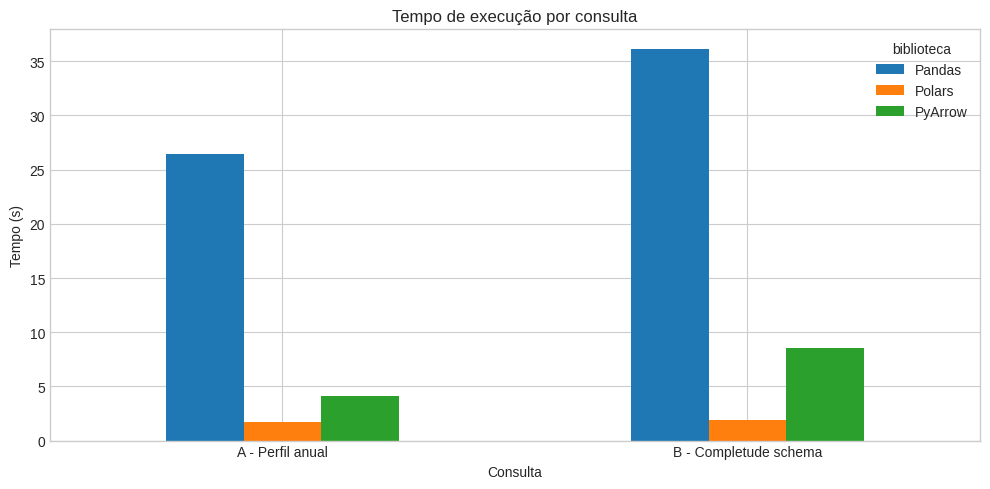

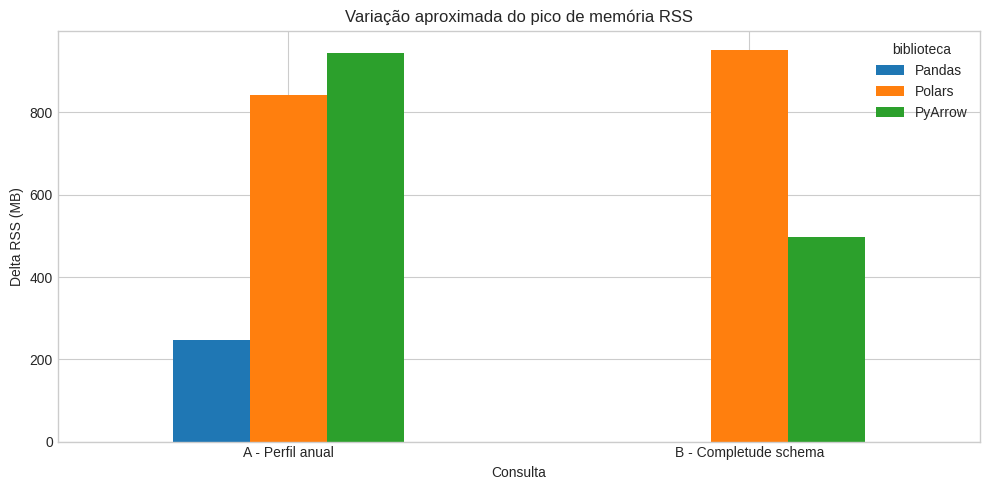

In [12]:
df_ok = df_benchmarks[df_benchmarks['status'].eq('ok')].copy()
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 5))
pivot_tempo = df_ok.pivot(index='consulta', columns='biblioteca', values='tempo_s')
pivot_tempo.plot(kind='bar', ax=ax)
ax.set_title('Tempo de execução por consulta')
ax.set_xlabel('Consulta')
ax.set_ylabel('Tempo (s)')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
pivot_memoria = df_ok.pivot(index='consulta', columns='biblioteca', values='rss_delta_mb')
pivot_memoria.plot(kind='bar', ax=ax)
ax.set_title('Variação aproximada do pico de memória RSS')
ax.set_xlabel('Consulta')
ax.set_ylabel('Delta RSS (MB)')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
plt.show()

## 9) Ranking Final

In [13]:
ranking = (
    df_ok.sort_values(['consulta', 'tempo_s'])
    .assign(posicao=lambda df: df.groupby('consulta')['tempo_s'].rank(method='first'))
    [['consulta', 'posicao', 'biblioteca', 'tempo_s', 'rss_delta_mb', 'linhas_resultado']]
)

display(ranking)

,consulta,posicao,biblioteca,tempo_s,rss_delta_mb,linhas_resultado
2,A - Perfil anual,1.0,Polars,1.669104,843.480469,31
1,A - Perfil anual,2.0,PyArrow,4.149917,945.082031,31
0,A - Perfil anual,3.0,Pandas,26.490834,247.015625,31
5,B - Completude schema,1.0,Polars,1.932204,951.382812,31
4,B - Completude schema,2.0,PyArrow,8.565809,497.703125,31
3,B - Completude schema,3.0,Pandas,36.131804,0.000000,31
